In [1]:
#Data creation 
import pandas as pd
import numpy as np
import random
np.random.seed(42)
num_records = 2500
education_levels = [
    "High School",
    "Bachelor",
    "Master",
    "PhD"
]

job_roles = [
    "Software Engineer",
    "Data Analyst",
    "Data Scientist",
    "Manager",
    "HR",
    "DevOps Engineer"
]

company_types = [
    "Startup",
    "MNC",
    "Government"
]
ages = np.random.randint(21, 60, num_records)

experience = np.random.randint(0, 35, num_records)

education = np.random.choice(education_levels, num_records)

skills_score = np.random.randint(40, 100, num_records)

certifications = np.random.randint(0, 10, num_records)

job_role = np.random.choice(job_roles, num_records)

company_type = np.random.choice(company_types, num_records)

#Salary Calculation Logic

base_salary = 25000

#EDUCATION BONUS
education_bonus = {
    "High School": 0,
    "Bachelor": 10000,
    "Master": 20000,
    "PhD": 35000
}

#JOB ROLE BONUS
job_bonus = {
    "Software Engineer": 25000,
    "Data Analyst": 15000,
    "Data Scientist": 35000,
    "Manager": 40000,
    "HR": 10000,
    "DevOps Engineer": 30000
}

# COMPANY TYPE BONUS
company_bonus = {
    "Startup": 5000,
    "MNC": 15000,
    "Government": 10000
}

salary = []

for i in range(num_records):

    emp_salary = (
        base_salary +
        (experience[i] * 2500) +            
        (skills_score[i] * 700) +            
        (certifications[i] * 3000) +         
        education_bonus[education[i]] +      
        job_bonus[job_role[i]] +             
        company_bonus[company_type[i]] +     
        np.random.randint(-10000, 10000)     
    )

    salary.append(emp_salary)
employee_df = pd.DataFrame({
    "Age": ages,
    "Education": education,
    "Experience": experience,
    "SkillsScore": skills_score,
    "Certifications": certifications,
    "JobRole": job_role,
    "CompanyType": company_type,
    "Salary": salary
})

employee_df.loc[
    employee_df.sample(frac=0.02).index,
    "SkillsScore"
] = np.nan

#Add Missing Values
employee_df.loc[
    employee_df.sample(frac=0.02).index,
    "Education"
] = np.nan

# Add Duplicate Records 
duplicates = employee_df.sample(20)

employee_df = pd.concat([employee_df, duplicates])

# Save Dataset as CSV File
employee_df.to_csv("employee_salary_dataset.csv", index=False)

print("Dataset Generated Successfully!")
print("\nTotal Records:", len(employee_df))

print("\nFirst 5 Rows:")
print(employee_df.head())

print("\nDataset Summary:")
print(employee_df.describe(include='all'))

Dataset Generated Successfully!

Total Records: 2520

First 5 Rows:
   Age    Education  Experience  SkillsScore  Certifications  \
0   59  High School          16         47.0               0   
1   49       Master          23         72.0               0   
2   35       Master          33         92.0               7   
3   28       Master          27         46.0               1   
4   41       Master          21         77.0               0   

             JobRole CompanyType  Salary  
0            Manager  Government  142121  
1                 HR         MNC  174443  
2     Data Scientist         MNC  270842  
3  Software Engineer     Startup  181712  
4  Software Engineer         MNC  183521  

Dataset Summary:
                Age Education   Experience  SkillsScore  Certifications  \
count   2520.000000      2470  2520.000000  2470.000000     2520.000000   
unique          NaN         4          NaN          NaN             NaN   
top             NaN  Bachelor          NaN    

Data Preprocessing

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
df = pd.read_csv("employee_salary_dataset.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

Dataset Loaded Successfully
Dataset Shape: (2520, 8)


In [4]:
# CHECK MISSING VALUES
print("\nMissing Values Before Handling:")
print(df.isnull().sum())


Missing Values Before Handling:
Age                0
Education         50
Experience         0
SkillsScore       50
Certifications     0
JobRole            0
CompanyType        0
Salary             0
dtype: int64


In [5]:
# HANDLE MISSING VALUES
# Fill missing Education values using Mode
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])

In [6]:
# Fill missing SkillsScore values using Mean
df["SkillsScore"] = df["SkillsScore"].fillna(df["SkillsScore"].mean())

In [7]:
# REMOVE DUPLICATE RECORDS
duplicate_count = df.duplicated().sum()
print("\nDuplicate Records Found:", duplicate_count)


Duplicate Records Found: 20


In [8]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [9]:
# DATA VALIDATION
df = df[(df["Age"] >= 18) & (df["Age"] <= 65)]
df = df[df["Experience"] >= 0]
df = df[df["Salary"] > 0]

In [10]:
# ENCODE CATEGORICAL FEATURES
label_encoder = LabelEncoder()
categorical_columns = ["Education","JobRole","CompanyType"]

In [11]:
# Encode categorical columns
for column in categorical_columns:df[column] = label_encoder.fit_transform(df[column])

FEATURE SCALING

In [12]:
scaler = StandardScaler()
numerical_columns = ["Age","Experience","SkillsScore","Certifications"]

In [13]:
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

FINAL DATASET CHECK

In [14]:
print("\nMissing Values After Handling:")
print(df.isnull().sum())
print("\nProcessed Dataset Shape:", df.shape)
print("\nFirst 5 Rows of Processed Dataset:")
print(df.head())


Missing Values After Handling:
Age               0
Education         0
Experience        0
SkillsScore       0
Certifications    0
JobRole           0
CompanyType       0
Salary            0
dtype: int64

Processed Dataset Shape: (2500, 8)

First 5 Rows of Processed Dataset:
        Age  Education  Experience  SkillsScore  Certifications  JobRole  \
0  1.655649          1   -0.117063    -1.294482       -1.570843        4   
1  0.769213          2    0.582597     0.179157       -1.570843        3   
2 -0.471796          2    1.582112     1.358068        0.841597        1   
3 -1.092301          2    0.982403    -1.353427       -1.226209        5   
4  0.060065          2    0.382694     0.473885       -1.570843        5   

   CompanyType  Salary  
0            0  142121  
1            1  174443  
2            1  270842  
3            2  181712  
4            1  183521  


In [15]:
df.to_csv("processed_employee_salary.csv", index=False)
print("\nProcessed Dataset Saved Successfully!")


Processed Dataset Saved Successfully!


Exploratory Data Analysis (EDA)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("employee_salary_dataset.csv")

In [18]:
print("First 5 Rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

First 5 Rows:
   Age    Education  Experience  SkillsScore  Certifications  \
0   59  High School          16         47.0               0   
1   49       Master          23         72.0               0   
2   35       Master          33         92.0               7   
3   28       Master          27         46.0               1   
4   41       Master          21         77.0               0   

             JobRole CompanyType  Salary  
0            Manager  Government  142121  
1                 HR         MNC  174443  
2     Data Scientist         MNC  270842  
3  Software Engineer     Startup  181712  
4  Software Engineer         MNC  183521  

Dataset Shape:
(2520, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             2520 non-null   int64  
 1   Education       2470 non-null   object 
 2   Expe

In [19]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                0
Education         50
Experience         0
SkillsScore       50
Certifications     0
JobRole            0
CompanyType        0
Salary             0
dtype: int64


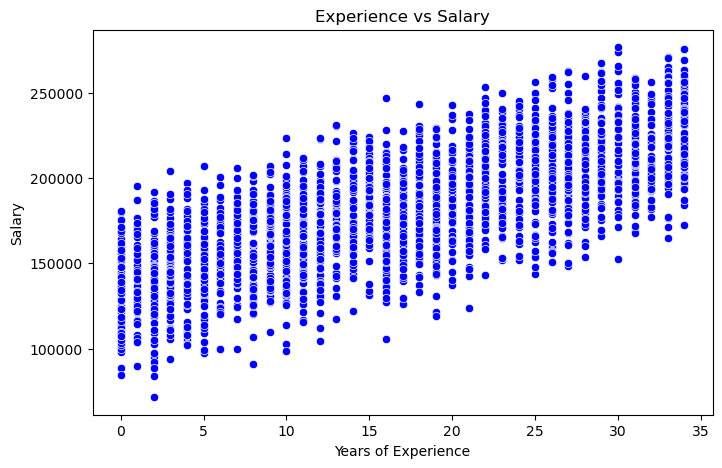

In [20]:
#Relationship Between Experience and Salary
plt.figure(figsize=(8,5))
sns.scatterplot(x="Experience",y="Salary",data=df,color="blue")
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

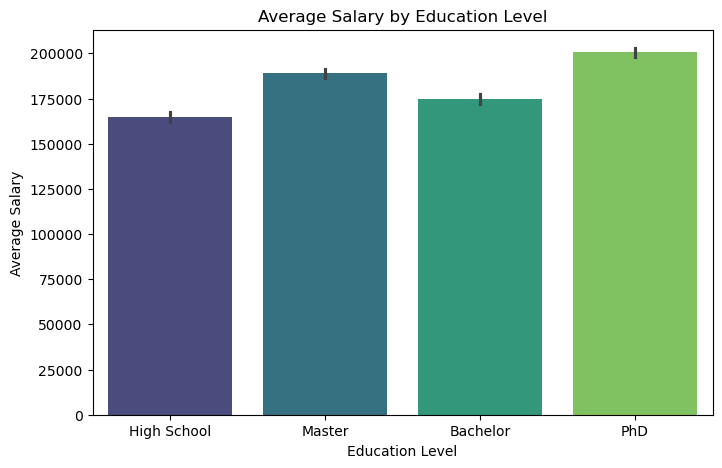

In [21]:
# Average Salary by Education Level
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.barplot(x="Education",y="Salary",hue="Education",data=df,palette="viridis",legend=False)
plt.title("Average Salary by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Salary")
plt.show()

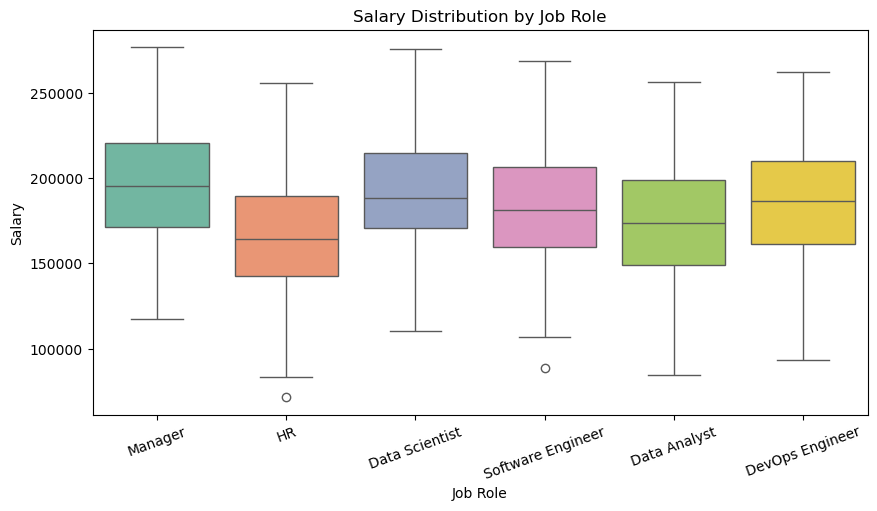

In [22]:
# Salary Distribution Across Job Roles
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(x="JobRole",y="Salary",hue="JobRole",data=df,palette="Set2",legend=False)
plt.title("Salary Distribution by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Salary")
plt.xticks(rotation=20)
plt.show()

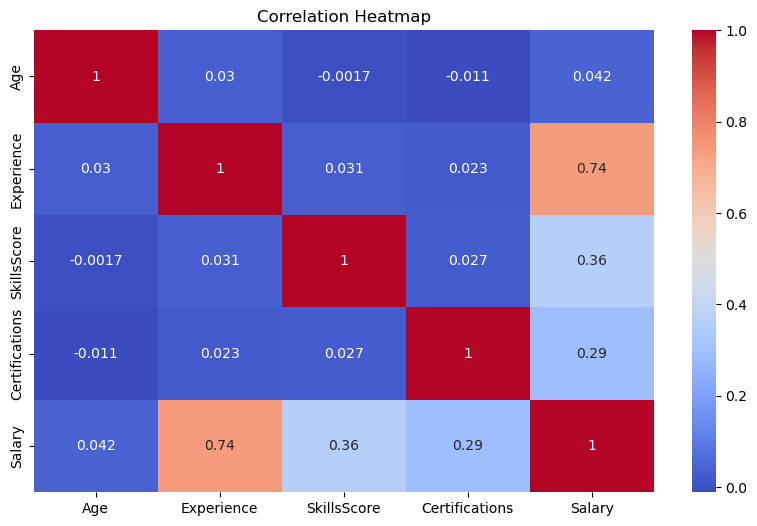

In [23]:
# Correlation Between Numerical Features
plt.figure(figsize=(10,6))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

VISUALIZATION

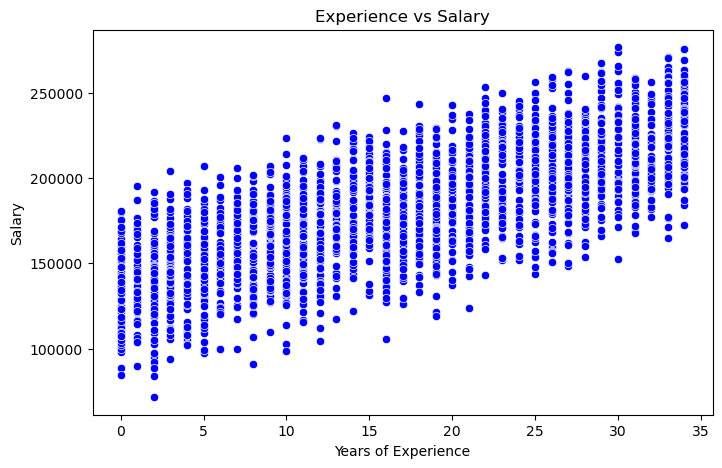

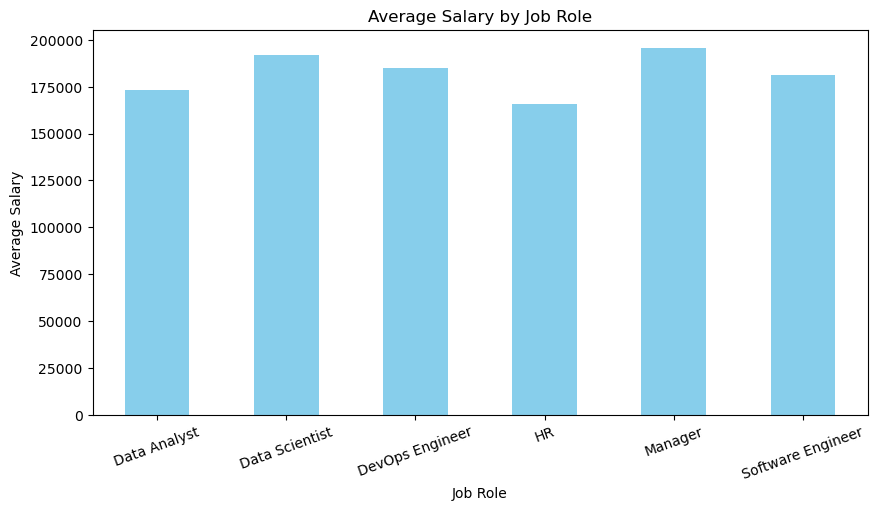

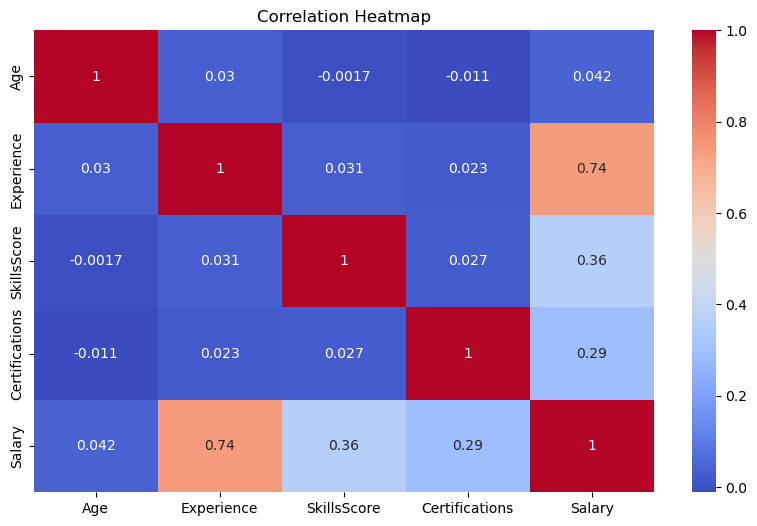

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Experience",y="Salary",data=df,color="blue")
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()
plt.figure(figsize=(10,5))
average_salary = df.groupby("JobRole")["Salary"].mean()
average_salary.plot(kind="bar",color="skyblue")
plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")
plt.xticks(rotation=20)
plt.show()
plt.figure(figsize=(10,6))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("employee_salary_dataset.csv")

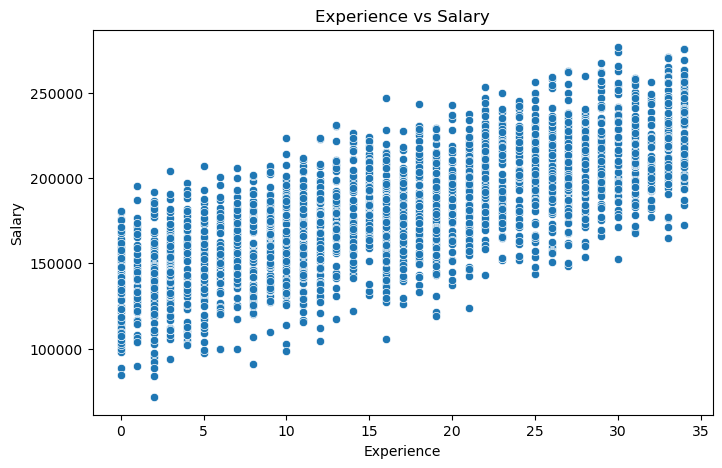

In [26]:
# Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x="Experience",y="Salary",data=df)
plt.title("Experience vs Salary")
plt.show()

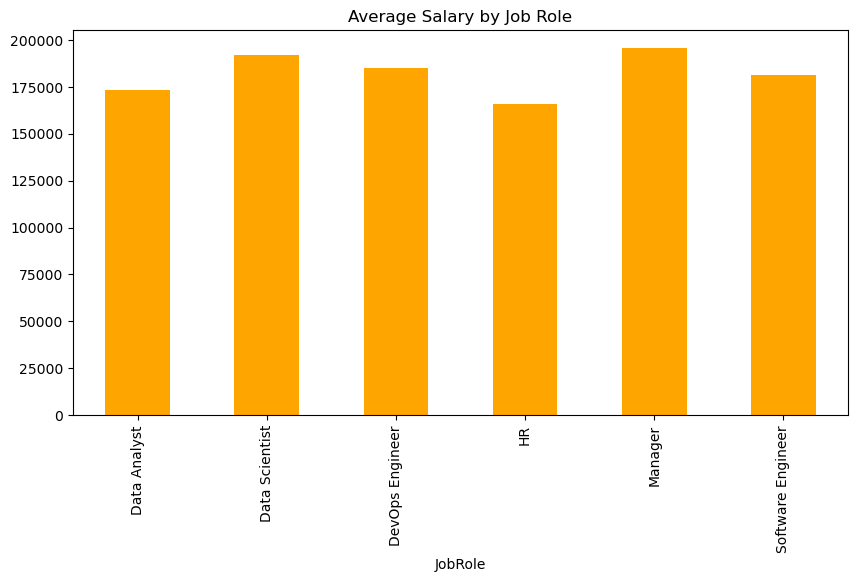

In [27]:
# Bar Chart
plt.figure(figsize=(10,5))
df.groupby("JobRole")["Salary"].mean().plot(kind="bar",color="orange")
plt.title("Average Salary by Job Role")
plt.show()

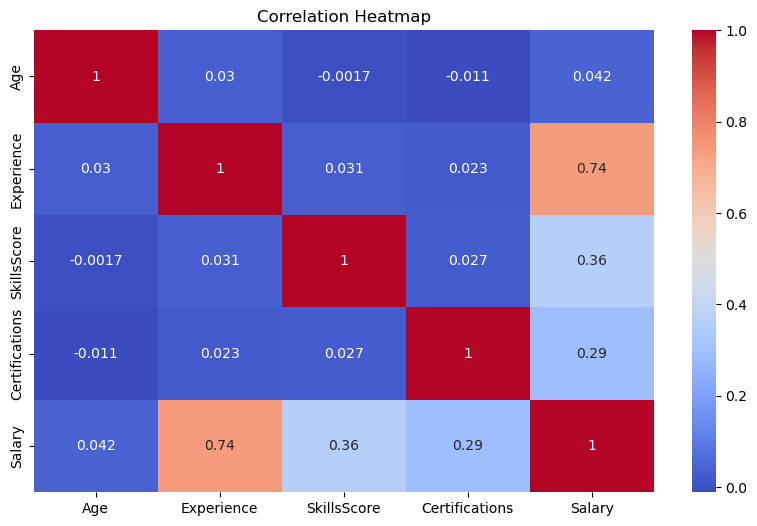

In [28]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

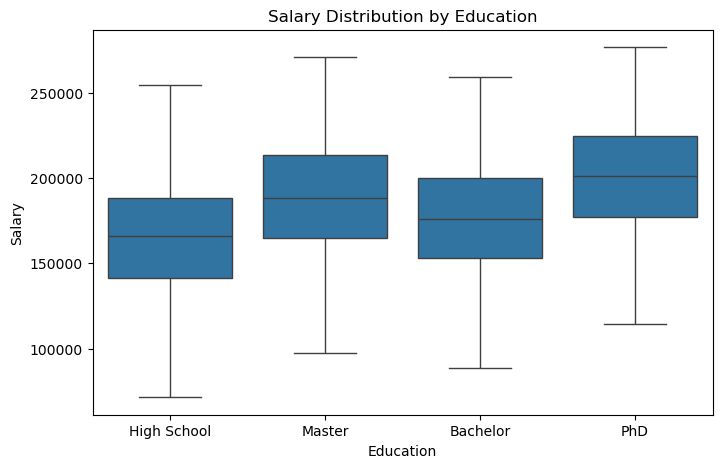

In [29]:
# Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Education",y="Salary",data=df)
plt.title("Salary Distribution by Education")
plt.show()

Machine Learning Model

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [31]:
# Features

In [32]:
X = df.drop("Salary", axis=1)
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (2016, 7)
Testing Data Shape: (504, 7)


Model Evaluation

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [34]:
df = pd.read_csv("processed_employee_salary.csv")

In [35]:
# Features and Target Variable
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [36]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [37]:
#Model Training
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
#Predictions
y_pred = model.predict(X_test)

In [39]:
#Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [40]:
# Display Results
print("Machine Learning Model Results")
print("\nMean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Machine Learning Model Results

Mean Absolute Error: 9561.85606
Root Mean Squared Error: 12159.756532814157
R2 Score: 0.8863874125118242


Interactive Prediction System

In [41]:
#EMPLOYEE SALARY PREDICTION SYSTEM
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [42]:
df = pd.read_csv("processed_employee_salary.csv")

In [43]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [44]:
# Train Machine Learning Model
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
# education_encoder = LabelEncoder()
jobrole_encoder = LabelEncoder()
company_encoder = LabelEncoder()
education_encoder = LabelEncoder()
education_encoder.fit(["High School","Bachelor","Master","PhD"])
jobrole_encoder.fit(["Software Engineer","Data Analyst","Data Scientist","Manager","HR","DevOps Engineer"            
])
company_encoder.fit(["Startup","MNC","Government"])
try:
    print("\nEmployee Salary Prediction System")
    age = int(input("Enter Age: "))
    education = input("Enter Education Level ""(High School/Bachelor/Master/PhD): ")
    experience = int(input("Enter Years of Experience: ")
    )
    skills_score = int(input("Enter Skills Score (0-100): ")
    )
    certifications = int(input("Enter Number of Certifications: ")
    )
    job_role = input("Enter Job Role "
        "(Software Engineer/Data Analyst/"
        "Data Scientist/Manager/HR/"
        "DevOps Engineer): "
    )
    company_type = input("Enter Company Type ""(Startup/MNC/Government): ")
    if age < 18 or age > 65:
        raise ValueError("Age must be between 18 and 65.")
    if experience < 0:
        raise ValueError(
            "Experience cannot be negative."
        )
    if skills_score < 0 or skills_score > 100:
        raise ValueError("Skills Score must be between 0 and 100.")

    if certifications < 0:
        raise ValueError("Certifications cannot be negative.")
    education_encoded = education_encoder.transform([education])[0]

    jobrole_encoded = jobrole_encoder.transform([job_role])[0]
    company_encoded = company_encoder.transform([company_type])[0]
    input_data = pd.DataFrame([{
        "Age": age,
        "Education": education_encoded,
        "Experience": experience,
        "SkillsScore": skills_score,
        "Certifications": certifications,
        "JobRole": jobrole_encoded,
        "CompanyType": company_encoded
    }])
    predicted_salary = model.predict(input_data)
    print("\n===== Prediction Result =====")
    print( f"Predicted Employee Salary:"f"₹{predicted_salary[0]:,.2f}")
except ValueError as ve:
    print("\nInput Error:", ve)
except Exception as e:

    print("\nUnexpected Error:", e)


Employee Salary Prediction System


Enter Age:  30
Enter Education Level (High School/Bachelor/Master/PhD):  Master
Enter Years of Experience:  5
Enter Skills Score (0-100):  85
Enter Number of Certifications:  3
Enter Job Role (Software Engineer/Data Analyst/Data Scientist/Manager/HR/DevOps Engineer):  Data Scientist
Enter Company Type (Startup/MNC/Government):  MNC



===== Prediction Result =====
Predicted Employee Salary:₹251,423.04


In [46]:
#ERROR HANDLING
try:
    age = int(input("Enter Age: "))
    education = input("Enter Education Level (High School/Bachelor/Master/PhD): ")
    experience = int(input("Enter Years of Experience: "))
    skills_score = int(input("Enter Skills Score (0-100): "))
    certifications = int(input("Enter Number of Certifications: "))
    job_role = input("Enter Job Role: ")
    company_type = input("Enter Company Type (Startup/MNC/Government): ")
 # INPUT VALIDATION
    if age < 18 or age > 65:
        raise ValueError("Age must be between 18 and 65.")

    if experience < 0:
        raise ValueError("Experience cannot be negative.")

    if skills_score < 0 or skills_score > 100:
        raise ValueError("Skills Score must be between 0 and 100.")

    if certifications < 0:
        raise ValueError("Certifications cannot be negative.")

    valid_education = [
        "High School",
        "Bachelor",
        "Master",
        "PhD"
    ]

    if education not in valid_education:
        raise ValueError("Invalid Education Level.")

    print("\nAll Inputs Are Valid!")

except ValueError as ve:
    print("\nInput Error:", ve)

except Exception as e:
    print("\nUnexpected Error:", e)

finally:
    print("\nProgram Executed Successfully.")

Enter Age:  30
Enter Education Level (High School/Bachelor/Master/PhD):  Master
Enter Years of Experience:  5
Enter Skills Score (0-100):  85
Enter Number of Certifications:  3
Enter Job Role:  Data Scientist
Enter Company Type (Startup/MNC/Government):  MNC



All Inputs Are Valid!

Program Executed Successfully.
